# Disease classification heatmap

Methods x diseases, AUROC and AUPR. Two side-by-side panels (AUROC | AUPR), with the seven diseases grouped by category: Mal-ID-only, Hybrid, and External-only.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Config

In [2]:
METHODS = [
    "Emerson 2017",
    "Ostmeyer 2019",
    "VJ-gkmer (LogReg)",
    "VJ-gkmer (XGBoost)",
    "ABMIL",
    "GIANA",
    "DeepRC",
    "DeepTCR",
    "Mal-ID",
]

DISEASE_GROUPS = [
    ("Mal-ID only", ["HIV", "Lupus", "Influenza", "COVID-19"]),
    ("Hybrid", ["T1D"]),
    ("External only", ["TB", "RA"]),
]
DISEASES = [d for _, ds in DISEASE_GROUPS for d in ds]

## Results table

Hardcoded results from the benchmarking spreadsheet.
- T1D values come from the merged Mal-ID + Mitchell evaluation.
- "Gapped k-mer + V/J (LR)" = "Ensemble regression / Ensemble" column.
- "Gapped k-mer + V/J (XGBoost)" results are not yet available.
- ABMIL = "ABMIL with CNN encoder / All features" column.
- Mal-ID = "Mal-ID / Ensemble" column (only run on Mal-ID-only diseases).

In [3]:
NA = np.nan
RESULTS = {
    # method: {disease: (auroc, aupr)}
    "Emerson 2017": {
        "HIV":       (0.9128, 0.8265),
        "Lupus":     (0.7740, 0.6635),
        "Influenza": (0.8218, 0.6646),
        "COVID-19":  (0.8860, 0.7045),
        "T1D":       (0.8815, 0.8506),
        "TB":        (0.5187, 0.4339),
        "RA":        (0.4956, 0.7648),
    },
    "Ostmeyer 2019": {
        "HIV":       (0.8005, 0.6214),
        "Lupus":     (0.6466, 0.3675),
        "Influenza": (0.4201, 0.1531),
        "COVID-19":  (0.6484, 0.3323),
        "T1D":       (0.5284, 0.8006),
        "TB":        (0.5933, 0.5465),
        "RA":        (0.5284, 0.8006),
    },
    "VJ-gkmer (LogReg)": {
        "HIV":       (0.8847, 0.7512),
        "Lupus":     (0.9017, 0.7375),
        "Influenza": (0.9802, 0.8521),
        "COVID-19":  (0.9239, 0.8176),
        "T1D":       (0.9642, 0.9598),
        "TB":        (0.4869, 0.4630),
        "RA":        (0.5000, 0.7872),
    },
    "VJ-gkmer (XGBoost)": {
        "HIV":       (NA, NA),
        "Lupus":     (NA, NA),
        "Influenza": (NA, NA),
        "COVID-19":  (NA, NA),
        "T1D":       (NA, NA),
        "TB":        (NA, NA),
        "RA":        (NA, NA),
    },
    "ABMIL": {
        "HIV":       (0.8650, 0.6918),
        "Lupus":     (0.9272, 0.8394),
        "Influenza": (0.8292, 0.5157),
        "COVID-19":  (0.8095, 0.6274),
        "T1D":       (NA, NA),
        "TB":        (NA, NA),
        "RA":        (NA, NA),
    },
    "GIANA": {
        "HIV":       (0.6721, 0.5796),
        "Lupus":     (0.7913, 0.5687),
        "Influenza": (0.8815, 0.8317),
        "COVID-19":  (0.4986, 0.3947),
        "T1D":       (NA, NA),
        "TB":        (NA, NA),
        "RA":        (NA, NA),
    },
    "DeepRC": {
        "HIV":       (0.8627, 0.7435),
        "Lupus":     (0.7963, 0.6791),
        "Influenza": (0.7185, 0.4251),
        "COVID-19":  (0.7667, 0.5778),
        "T1D":       (NA, NA),
        "TB":        (NA, NA),
        "RA":        (NA, NA),
    },
    "DeepTCR": {
        "HIV":       (0.9100, 0.7925),
        "Lupus":     (0.9201, 0.8142),
        "Influenza": (0.7795, 0.3284),
        "COVID-19":  (0.9394, 0.8250),
        "T1D":       (NA, NA),
        "TB":        (NA, NA),
        "RA":        (NA, NA),
    },
    "Mal-ID": {
        "HIV":       (0.9131, 0.7308),
        "Lupus":     (0.9159, 0.7910),
        "Influenza": (0.9751, 0.9535),
        "COVID-19":  (0.9859, 0.9386),
        "T1D":       (NA, NA),
        "TB":        (NA, NA),
        "RA":        (NA, NA),
    },
}

## Build dataframes

In [4]:
def load_results():
    auroc = pd.DataFrame(
        {d: {m: RESULTS[m][d][0] for m in METHODS} for d in DISEASES}
    ).reindex(index=METHODS, columns=DISEASES)
    aupr = pd.DataFrame(
        {d: {m: RESULTS[m][d][1] for m in METHODS} for d in DISEASES}
    ).reindex(index=METHODS, columns=DISEASES)
    return auroc, aupr


auroc, aupr = load_results()
auroc

,HIV,Lupus,Influenza,COVID-19,T1D,TB,RA
Emerson 2017,0.9128,0.7740,0.8218,0.8860,0.8815,0.5187,0.4956
Ostmeyer 2019,0.8005,0.6466,0.4201,0.6484,0.5284,0.5933,0.5284
VJ-gkmer (LogReg),0.8847,0.9017,0.9802,0.9239,0.9642,0.4869,0.5000
VJ-gkmer (XGBoost),NaN,NaN,NaN,NaN,NaN,NaN,NaN
ABMIL,0.8650,0.9272,0.8292,0.8095,NaN,NaN,NaN
GIANA,0.6721,0.7913,0.8815,0.4986,NaN,NaN,NaN
DeepRC,0.8627,0.7963,0.7185,0.7667,NaN,NaN,NaN
DeepTCR,0.9100,0.9201,0.7795,0.9394,NaN,NaN,NaN
Mal-ID,0.9131,0.9159,0.9751,0.9859,NaN,NaN,NaN


## Plot helpers

In [ ]:
def plot_heatmap_panel(ax, values, title, vmin, vmax, cmap="viridis", show_yticks=True):
    """One heatmap panel covering all diseases, with bold dividers between groups."""
    arr = values.loc[METHODS, DISEASES].values
    im = ax.imshow(arr, aspect="auto", vmin=vmin, vmax=vmax, cmap=cmap)

    ax.set_xticks(range(len(DISEASES)))
    ax.set_xticklabels(DISEASES, rotation=45, ha="right", fontsize=12)
    ax.set_yticks(range(len(METHODS)))
    if show_yticks:
        ax.set_yticklabels(METHODS, fontsize=12)
    else:
        ax.set_yticklabels([])
    ax.set_title(title, fontsize=15, pad=7) # fontweight="bold"

    mid = (vmin + vmax) / 2
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            v = arr[i, j]
            txt = "N/A" if np.isnan(v) else f"{v:.2f}"
            color = "white" if (not np.isnan(v) and v < mid) else "black"
            ax.text(j, i, txt, ha="center", va="center", color=color, fontsize=12)

    # Bold dividers between disease categories.
    boundary = 0
    for _, group in DISEASE_GROUPS[:-1]:
        boundary += len(group)
        ax.axvline(boundary - 0.5, color="black", linewidth=3.5)
    return im


def _auto_range(df):
    return float(np.nanmin(df.values)), float(np.nanmax(df.values))


def make_figure(auroc_df, aupr_df, out_path=None):
    fig, axes = plt.subplots(
        1, 2, figsize=(14, 6), constrained_layout=True,
        gridspec_kw={"wspace": 0.15},
    )
    auroc_lo, auroc_hi = _auto_range(auroc_df)
    aupr_lo, aupr_hi = _auto_range(aupr_df)
    vmin, vmax = min(auroc_lo, aupr_lo), max(auroc_hi, aupr_hi)
    plot_heatmap_panel(axes[0], auroc_df, "AUROC", vmin, vmax, show_yticks=True)
    im = plot_heatmap_panel(axes[1], aupr_df, "AUPRC", vmin, vmax, show_yticks=False)
    fig.colorbar(im, ax=axes, shrink=0.85)
    if out_path:
        fig.savefig(out_path, dpi=200, bbox_inches="tight")
    return fig

## Render

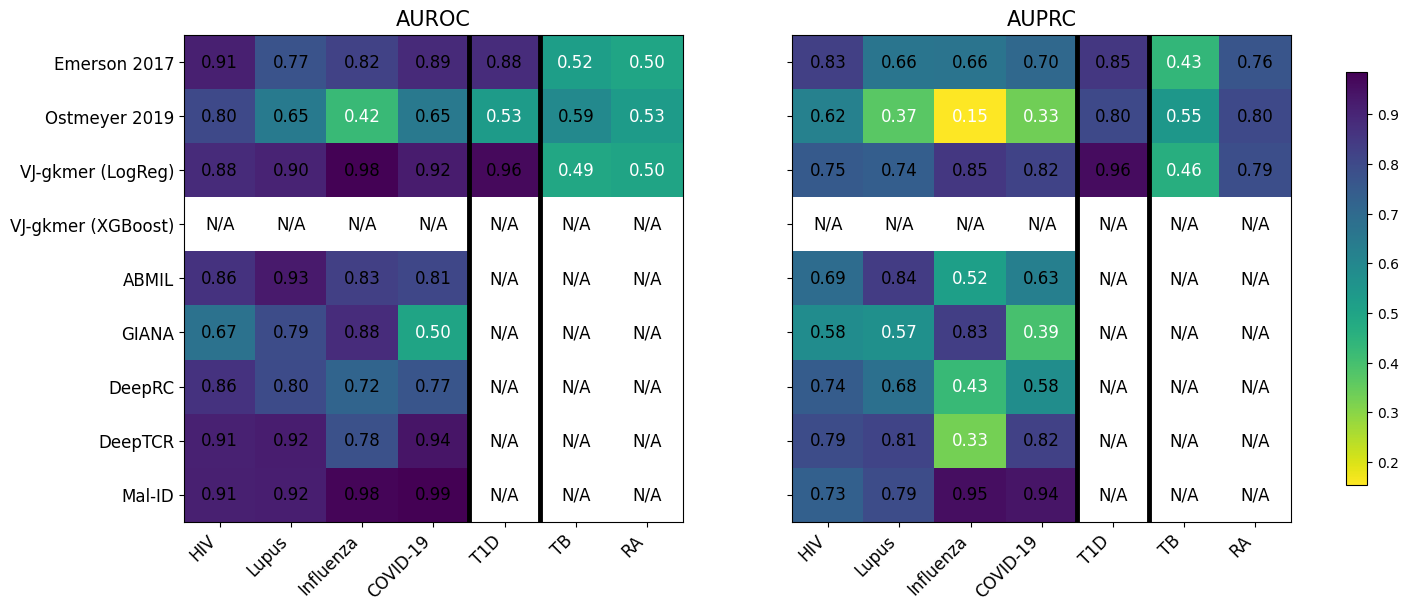

In [6]:
fig = make_figure(auroc, aupr, out_path="disease_classification_heatmap.pdf")
plt.show()